Pythonによる微分方程式の数値計算

はじめに
　物理現象、生理現象、病気の蔓延や社会現象など様々な現象を微分方程式に表すことができる。しかし、ほとんどの場合、紙と鉛筆では解けない。このような時、コンピュータを用いた数値解析を行う。ここでは、最も一般的に使われているルンゲ＝クッタ法（Runge-Kutta method）を用いてコロナウイルス陽性者のデータを SIR モデルで解析する。第 1 回物理学実験テキスト「統計処理 (最小 2 乗法)」に準拠するので、参考にせよ。初めから難しいことをしても分からないので、簡単な手法およびモデルから始めて、数理解析の専門的な話題まで行く。

1　オイラー法によるロジステック方程式の解法

Logistic equation (統計処理 (最小 2 乗法)式 (26))は、フラスコの中の大腸菌の数のような、限られた栄養源の中での生物の繁殖を表す。

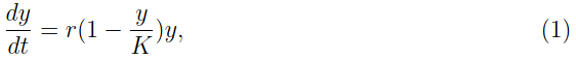

この微分方程式の解は、t=0のとき、y=y0とすると、

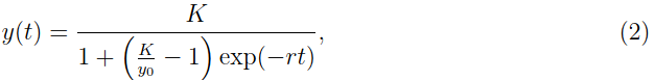

となる。一方で、dtを微小時間とすると、微分の定義から、

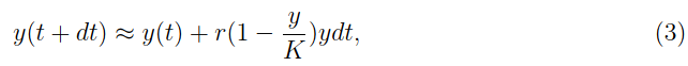

となる。したがって、時刻tにおけるy(t)が分かれば、時刻t+dtにおける近似値を式(3)から求めることができる。このようにして微分方程式の数値解を求める方法をEuler法という。以下に添付したpython codeは、このためのものである。コピーして実行せよ。


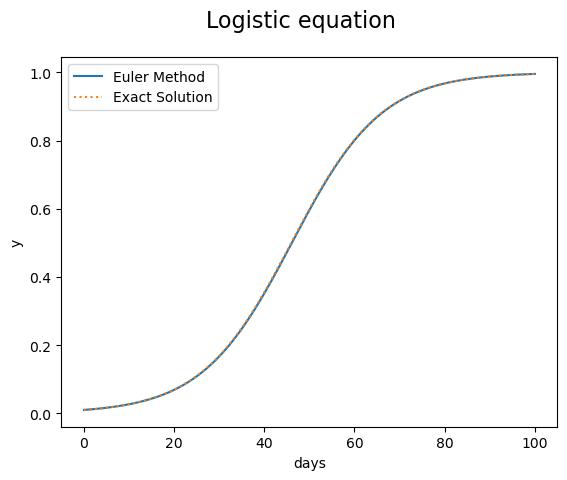

In [4]:
#　Euler法によるロジステック方程式の数値解
import numpy as np                    #数値計算用モジュールを読み込む
import matplotlib.pyplot as plt       #描画用のモジュールを読み込む

tmax=100    #初期値
dt=0.1      #変えて見よ　例えば　1
y0=0.01
r =0.1
K=1
y=[]        #配列（リスト）であることの宣言
t=[]

def Exactlogistics(t,y0,r,K):   #微分方程式の解析解(オイラー法との比較)
    return K/(1+ (K/y0-1)*np.exp(-r*t))

def logistics(y, r, K):
    return r*(1-y/K)*y

def EulerOneStepForward(y, dt):  
    return logistics(y,r,K)*dt+y

tprev=0
yprev=y0
while tprev < tmax :
    y.append(yprev)
    t.append(tprev)
    yprev = EulerOneStepForward(yprev, dt)
    tprev +=  dt

plt.style.use('default')             #描画スタイルは通常の形

fig, ax = plt.subplots()
fig.suptitle("Logistic equation", fontsize = 16)
ax.plot(t,y, label = "Euler Method")     #描画用データ作成(表示しないがここで図を作成)

yexact=[Exactlogistics(tt,y0,r,K) for tt in t]
ax.plot(t,yexact,linestyle="dotted", label = "Exact Solution")  

ax.legend()
ax.set_xlabel("days")             
ax.set_ylabel("y")            

plt.show()                       #図を表示する


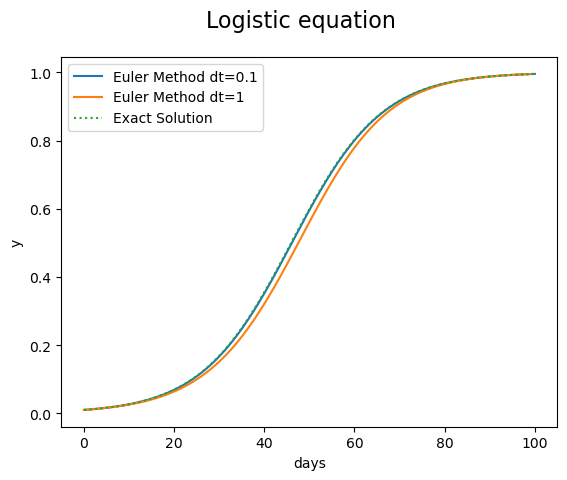

In [6]:
tmax=100    #初期値
dt=0.1      #変えて見よ　例えば　1
y0=0.01
r =0.1
K=1
y=[]        #配列（リスト）であることの宣言
t=[]

def Exactlogistics(t,y0,r,K):   #微分方程式の解析解(オイラー法との比較)
    return K/(1+ (K/y0-1)*np.exp(-r*t))

def logistics(y, r, K):
    return r*(1-y/K)*y

def EulerOneStepForward(y, dt):  
    return logistics(y,r,K)*dt+y

tprev=0
yprev=y0
while tprev < tmax :
    y.append(yprev)
    t.append(tprev)
    yprev = EulerOneStepForward(yprev, dt)
    tprev +=  dt


dt=1      #変えて見よ　例えば　1
y0=0.01
r =0.1
K=1
y2=[]        #配列（リスト）であることの宣言
t2=[]

tprev=0
yprev=y0
while tprev < tmax :
    y2.append(yprev)
    t2.append(tprev)
    yprev = EulerOneStepForward(yprev, dt)
    tprev +=  dt


plt.style.use('default')             #描画スタイルは通常の形

fig, ax = plt.subplots()
fig.suptitle("Logistic equation", fontsize = 16)
ax.plot(t,y, label = "Euler Method dt=0.1")     #描画用データ作成(表示しないがここで図を作成)
ax.plot(t2,y2, label = "Euler Method dt=1")     #描画用データ作成(表示しないがここで図を作成)


yexact=[Exactlogistics(tt,y0,r,K) for tt in t]
ax.plot(t,yexact,linestyle="dotted", label = "Exact Solution")  

ax.legend()
ax.set_xlabel("days")             
ax.set_ylabel("y")            

plt.show()                       #図を表示する


解析解とEuler法の両方が図示されるが、dt=0.1ではよく一致しているが、dt=1とすると微妙にずれる。

2  Lotka-Volterra equations

Logistic equationはフラスコに餌と大腸菌を入れて、大腸菌がどのように増えていくかを記述している。増えすぎると餌がなくなりそれ以上増えなくなる。ここでは、これを改良してもう少し複雑にしてみよう。

カナダにおけるカンジキウサギyとその捕食者であるカナダオオヤマネコzの個体数の変動は図のように奇妙な振る舞いをする。これは、ウサギは森の植物を食べて増えるが(1日あたりAy)、ヤマネコに捕食されて減る(1日あたり-Byz)。ヤマネコは、餌であるウサギの個体数に比例して増え(1日あたりCyz)、諸般の理由で死んでいく(1日あたりDz)。これを式にすると式(4),(5)となる。

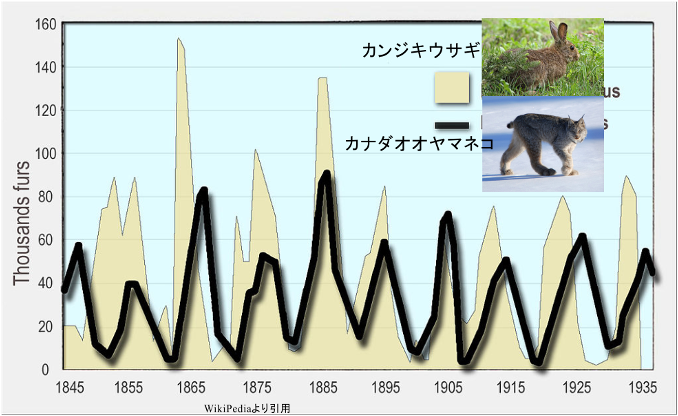
図1　カナダでの報告例

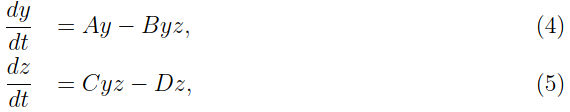

歴史的には魚やサメの個体数で作られた式でありLotka-Volterra equationsという。実例としてはうさぎとやまねこの例の方が有名である。

良さげな感じはあるが、全体として増加気味である。試しに、初期値のdtをdt=0.001とすると、増加傾向が減る。微分方程式の数値解で一番困るのは、結果が正しいのか否か分からないということ。多くの場合厳密解のある場合や、運動量・エネルギーなどの保存量でチェックする。これは有名な式なのでかなり詳しく解析され、色々なチェック方法があるが、どれもややこしい。

Text(0, 0.5, 'y, z')

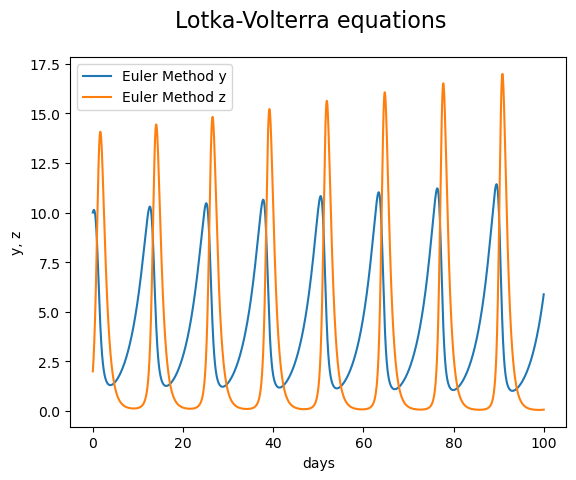

In [4]:
#  Euler法による Lotka-Volterra equations　の数値解
import numpy as np                    
import matplotlib.pyplot as plt       

tmax=100    #初期値
dt=0.01     
y0=10
z0=2
y=[]        #配列（リスト）であることの宣言
z=[]
t=[]
A, B, C, D = 0.3, 0.1, 0.3, 1.3

def LotVol(y,z,A,B,C,D):
    return A*y - B*y*z, C*y*z - D*z

def EulerOneStepForward(y,z,dt,A,B,C,D): 
    yy,zz=LotVol(y,z,A,B,C,D)
    return yy*dt + y, zz*dt+z

tprev=0
yprev=y0
zprev=z0
while tprev < tmax :
    y.append(yprev)
    z.append(zprev)
    t.append(tprev)
    yprev,zprev = EulerOneStepForward(yprev,zprev, dt,A,B,C,D)
    tprev +=  dt

plt.style.use('default')             #描画スタイルは通常の形

fig, ax = plt.subplots()
fig.suptitle("Lotka-Volterra equations", fontsize = 16)
ax.plot(t,y, label = "Euler Method y")    
ax.plot(t,z, label = "Euler Method z")  

ax.legend()
ax.set_xlabel("days")             
ax.set_ylabel("y, z")            

#plt.show()                       #図を表示する

3 　解析解の分かっている例

ここでは、式(6),(7)のように解析解を求められる例に対してEuler法を適用し、Lotka-Volterra equationsの数値解について考察しよう。

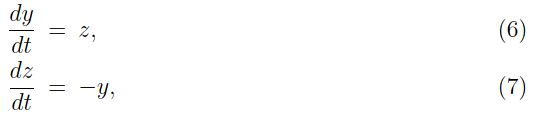

t=0のときy(0)=y0, z(0)=0の解は、

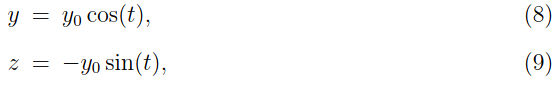

である。

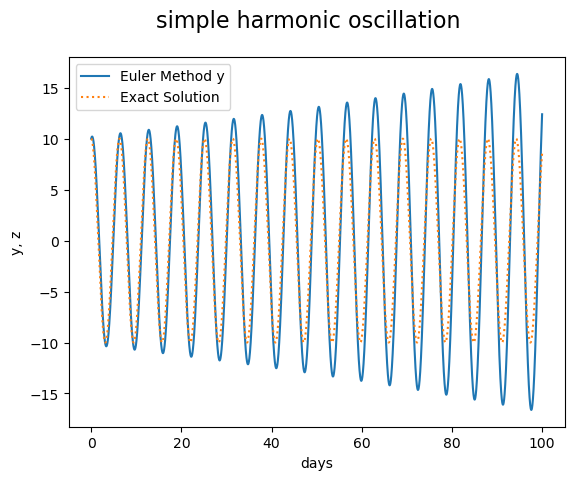

In [35]:
# Euler法　解析解の分かっている例と比較
import numpy as np                  #数値計算用モジュールを読み込む
import matplotlib.pyplot as plt     #描画用のモジュールを読み込む            

tmax=100    #初期値
dt=0.01     
y0=10
z0=2

y=[]        #配列（リスト）であることの宣言
z=[]
t=[]

def ExactSolution(t):
    return y0*np.cos(t)

def SinCos(y,z):
    return z, -y

def EulerOneStepForward(y,z,dt): 
    yy,zz=SinCos(y,z)
    return yy*dt + y, zz*dt+z

tprev=0
yprev=y0
zprev=z0
while tprev < tmax :
    y.append(yprev)
    z.append(zprev)
    t.append(tprev)
    yprev,zprev = EulerOneStepForward(yprev,zprev, dt)
    tprev += dt

plt.style.use('default')             #描画スタイルは通常の形

fig, ax = plt.subplots()
fig.suptitle("simple harmonic oscillation", fontsize = 16)
ax.plot(t,y, label = "Euler Method y")    
#ax.plot(t,z, label = "Euler Method z")  

yexact=[ ExactSolution(tt)  for tt in t]
ax.plot(t,yexact,linestyle="dotted", label = "Exact Solution")  

ax.legend()
ax.set_xlabel("days")             
ax.set_ylabel("y, z")            

plt.show()                       #図を表示する


かなりずれていることが分かる。dtを小さくすれば精度は上がるが、計算量が増えるので時間がかかったり、別な誤差が増えたりと、ろくなことはない。

4  Runge-Kutta method

微分方程式の数値解法は無数にあり、用途に応じて適切な手法を選ぶ必要があるが、その中にあって最も汎用性が高く多用されている方法はルンゲ＝クッタ法である:

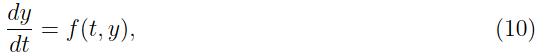

を解くために、以下のような計算をする。時刻tにおけるy(t)を用い、時刻t+hでのy(t+h)は、(慣例なので、dtのかわりにhを用いた。)

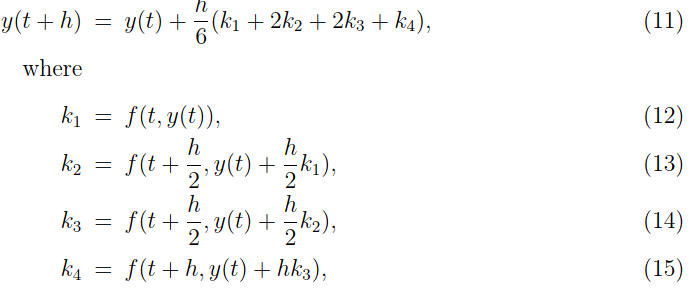

である。変数の数が多い場合(多元)への拡張は容易であり、2元のばあいには、以下のようになる。

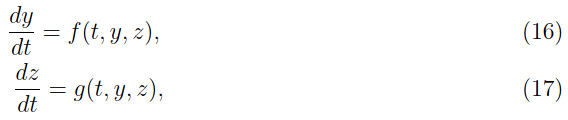

に対する数値解法：

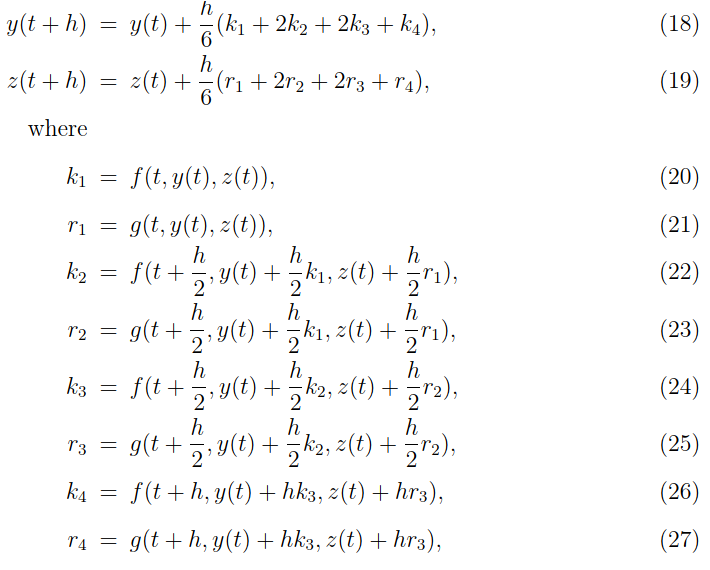


Text(0, 0.5, 'y, z')

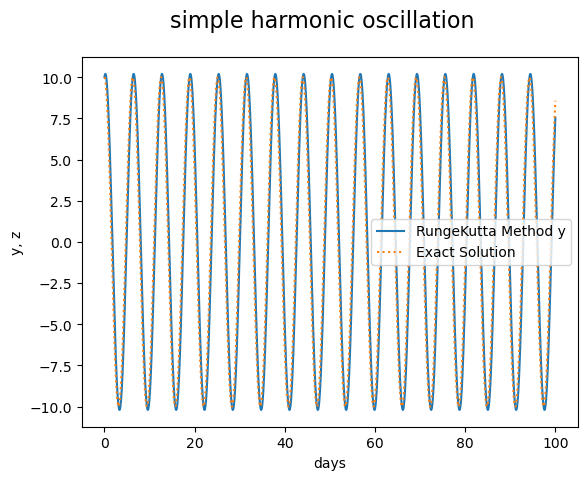

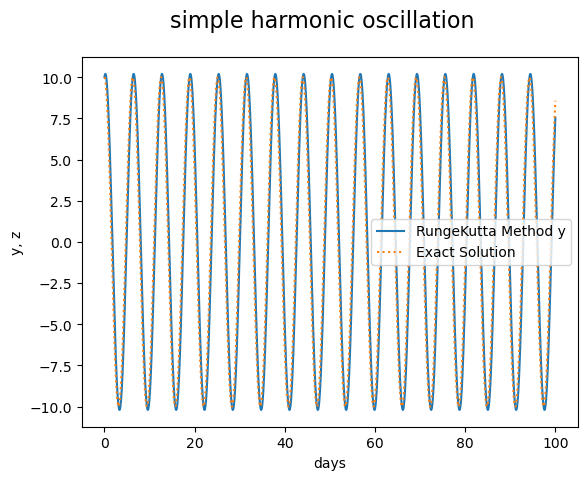

In [9]:
# Runge-Kutta method　解析解の分かっている例と比較
import numpy as np                    #数値計算用モジュールを読み込む
import matplotlib.pyplot as plt       #描画用のモジュールを読み込む            

tmax=100    #初期値
dt=0.01     
y0=10
z0=2

y=[]        #配列（リスト）であることの宣言
z=[]
t=[]

def ExactSolution(t):
    return y0*np.cos(t)

def SinCos(y,z):
    return z, -y

def EulerOneStepForward(y,z,dt): 
    yy,zz=SinCos(y,z)
    return yy*dt + y, zz*dt+z

def RungeKuttaOneStepForward(y,z,dt): 
    k1,r1=SinCos(y,z)
    k2,r2=SinCos(y+dt/2*k1, z+dt/2*r1)
    k3,r3=SinCos(y+dt/2*k2, z+dt/2*r2)
    k4,r4=SinCos(y+dt*k3, z+dt*r3)
    return (k1+2*k2+2*k3+k4)*dt/6 + y, (r1+2*r2+2*r3+r4)*dt/6 +z

tprev=0
yprev=y0
zprev=z0
while tprev < tmax :
    y.append(yprev)
    z.append(zprev)
    t.append(tprev)
    #yprev,zprev = EulerOneStepForward(yprev,zprev, dt)
    yprev,zprev = RungeKuttaOneStepForward(yprev,zprev, dt)
    tprev += dt

plt.style.use('default')             #描画スタイルは通常の形

fig, ax = plt.subplots()
fig.suptitle("simple harmonic oscillation", fontsize = 16)
ax.plot(t,y, label = "RungeKutta Method y")    
#ax.plot(t,z, label = "Euler Method z")  

yexact=[ ExactSolution(tt)  for tt in t]
ax.plot(t,yexact,linestyle="dotted", label = "Exact Solution")  

ax.legend()
ax.set_xlabel("days")             
ax.set_ylabel("y, z")            

plt.show()                       #図を表示する


ほとんど誤差がないことが分かる。率直な所、Euler法は誤差が大きく、用いられることは無い。通常の用途では、Runge-Kutta methodを用いれば十分である。通常でない例は、惑星の多体運動のように衝突するくらい近づいて高速になるような場合で、厳密なエネルギー保存が絶対に必要となるような場合であり、このような場合には更に別な数値解法を用いる。
　Euler法をけなしてしまったが、Euler法を用いたLotka-Volterra equationsの数値解法の解析は、その後に著しく進展し数理解析に新しい分野を作った。本テキストの最後に説明がある。


4  Runge-Kutta methodを用いたLotka-Volterra equations

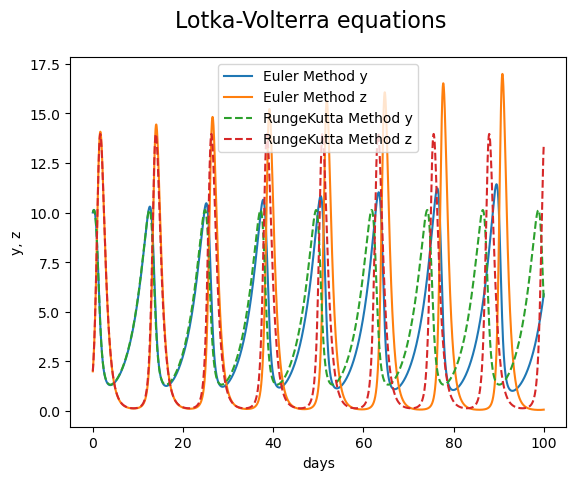

In [11]:
# Runge-Kutta methodを用いたLotka-Volterra equations
import numpy as np                     
import matplotlib.pyplot as plt                   

tmax=100    #初期値
dt=0.01     
y0=10
z0=2
yE=[]        #Euler法
zE=[]
yR=[]        #RungeKutta法
zR=[]
t=[]
A, B, C, D = 0.3, 0.1, 0.3, 1.3

def LotVol(y,z):
    return A*y - B*y*z, C*y*z - D*z

def EulerOneStepForward(y,z,dt): 
    yy,zz=LotVol(y,z)
    return yy*dt + y, zz*dt+z

def RungeKuttaOneStepForward(y,z,dt): 
    k1,r1=LotVol(y,z)
    k2,r2=LotVol(y+dt/2*k1, z+dt/2*r1)
    k3,r3=LotVol(y+dt/2*k2, z+dt/2*r2)
    k4,r4=LotVol(y+dt*k3, z+dt*r3)
    return (k1+2*k2+2*k3+k4)*dt/6 + y, (r1+2*r2+2*r3+r4)*dt/6 +z

tprev=0
yprevE=y0
zprevE=z0
yprevR=y0
zprevR=z0

while tprev < tmax :
    yE.append(yprevE)
    zE.append(zprevE)
    yR.append(yprevR)
    zR.append(zprevR)
    t.append(tprev)
    yprevE,zprevE = EulerOneStepForward(yprevE,zprevE, dt)
    yprevR,zprevR = RungeKuttaOneStepForward(yprevR,zprevR, dt)
    tprev += dt

plt.style.use('default')             #描画スタイルは通常の形

fig, ax = plt.subplots()
fig.suptitle("Lotka-Volterra equations", fontsize = 16)
ax.plot(t,yE, label = "Euler Method y")    
ax.plot(t,zE, label = "Euler Method z")  
ax.plot(t,yR, label = "RungeKutta Method y",linestyle='dashed')    
ax.plot(t,zR, label = "RungeKutta Method z",linestyle='dashed')  

ax.legend()
ax.set_xlabel("days")             
ax.set_ylabel("y, z")            

plt.show()                       #図を表示する


振幅の増大はオイラー法の誤差が原因であることが分かる。この誤差はRunge-Kutta法ならある程度回避できる。以下では、Runge-Kuttaを用いる。

5 　SIRモデル

SIRモデルは感染症の蔓延と回復を表す1つの方法である。1mlsq修正式(27)-(30)に簡単な説明がある。webにも情報が多いので、検索して調べよ。
未感染者(感受性保持者susceptible)の数をS ,感染者infectedの数をI, 免疫保持者recoveredの数をR,として

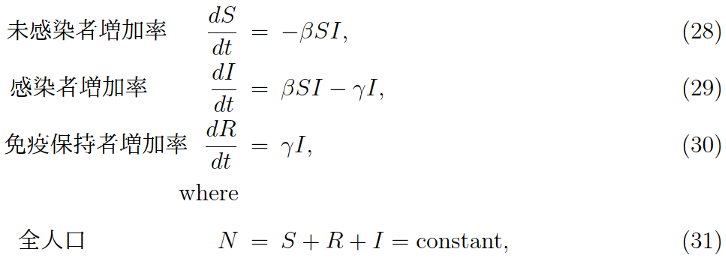

として記述する。γについては、式(29)の最後の項、-γIから、治癒日数と関連していることがわかる。この項だけなら、

$I(t) = I_0 exp(-\gamma t )$　　　　　　　　　　（32）

となるから、1/γは感染した人が治癒して感染者数が1/eに減少する日数を表す。

次にβの意味を考えてみる。式(29)の第1項に注目すると、感染者の増加率に関連していることが分かる。1人あたり毎日平均m人と接触すると仮定すると、そのうち感染している人の割合はI/N  (Nは全人口)であるから、 未感染者が感染者と接触する数は1日あたりm S I/N となる。 1回の接触で感染する確率をpとすれば、1日の間に生じる新たな感染者は、全体としてp m S I/N なので、式(29)第1項と比較して、β=pm/Nである。

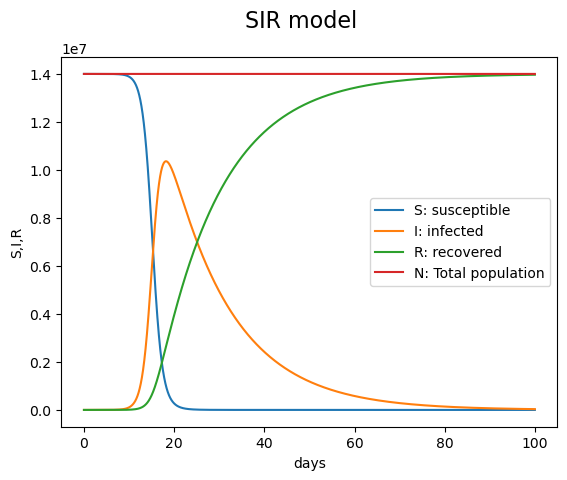

In [13]:
#　SIRモデル計算
import numpy as np                  
import matplotlib.pyplot as plt        

tmax=100        #初期値
dt=0.01     
N0 = 14000000    #　人口 1400万人
I0 = 10         #　初期感染者 10人
S0 = N0-10       #　未感染者　
R0 =0           #  初期免疫保持者　0
r = 1/14        #  14日程度で治癒する
b = 0.1*10/N0    #  p=0.1, m=10,  感染する確率

t = [ ]
S = [ ]
I = [ ]
R = [ ]
N = [ ]

def SIRmodel(S,I,R):
    return -b*S*I, b*S*I-r*I,r*I

def RungeKuttaOneStepForward(S,I,R, dt): 
    s1,i1,r1 =SIRmodel(S,I,R)
    s2,i2,r2 =SIRmodel(S+dt/2*s1, I+dt/2*i1, R+dt/2*r1)
    s3,i3,r3 =SIRmodel(S+dt/2*s2, I+dt/2*i2, R+dt/2*r2)
    s4,i4,r4 =SIRmodel(S+dt  *s3, I+dt  *i3, R + dt*r3)
    return (s1+2*s2+2*s3+s4)*dt/6 + S, (i1+2*i2+2*i3+i4)*dt/6 + I,  (r1+2*r2+2*r3+r4)*dt/6 + R

tprev=0
Sprev=S0
Iprev=I0
Rprev=R0

while tprev < tmax :
    S.append(Sprev)
    I.append(Iprev)
    R.append(Rprev)
    t.append(tprev)
    N.append(Sprev+Iprev+Rprev)
    Sprev,Iprev,Rprev = RungeKuttaOneStepForward(Sprev, Iprev,Rprev, dt)
    tprev += dt
    

plt.style.use('default')             #描画スタイルは通常の形

fig, ax = plt.subplots()
fig.suptitle("SIR model", fontsize = 16)
ax.plot(t,S, label = "S: susceptible")    
ax.plot(t,I, label = "I: infected")  
ax.plot(t,R, label = "R: recovered")    
ax.plot(t,N, label = "N: Total population")   

ax.legend()
ax.set_xlabel("days")             
ax.set_ylabel("S,I,R")            

plt.show()                       #図を表示する


6 　SIRモデルを現実に合わせる

先のSIRモデル計算と東京都が発表したCOVID-19陽性者数のデータを並べて表示するpython codeを以下に示す.報告データの陽性者数は1日あたりなのでIではなくβSIとしている.虫眼鏡をクリックして領域を選び,xをクリックすると,両者が一緒に表示されるが,ただ一緒に表示されるだけで現実に合わせたパラメータにはなっていない未完成プログラムである.


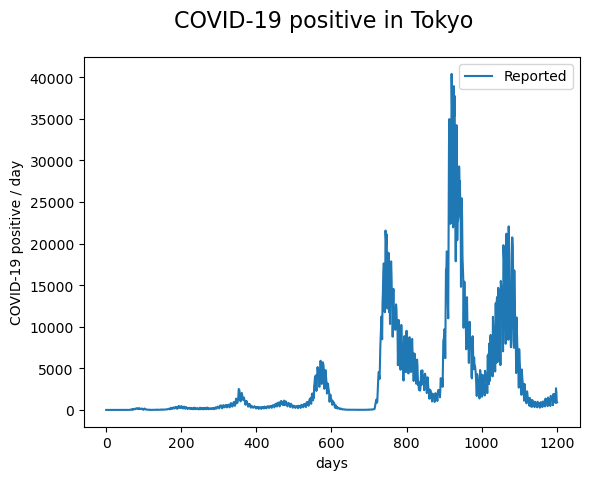

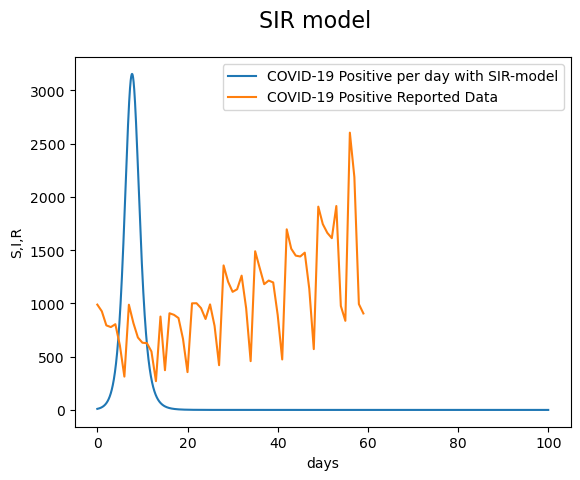

In [25]:
#未完成のプログラムである。各自修正せよ。
# SIRモデルと現実のデータの比較
import numpy as np                  
import matplotlib.pyplot as plt

pathdir ="./"  #各自修正　データファイルの場所
path = pathdir + "data20230505-20200120.txt"   #データファイル名
           #   https://stopcovid19.metro.tokyo.lg.jp/　から引用
with open(path) as fileobj:          
    dlist =  fileobj.readlines()

datalist = dlist[::-1]     
data = [ int(s) for s in  datalist]  #

plt.style.use('default')             #描画スタイルは通常の形

fig, ax = plt.subplots()
fig.suptitle("COVID-19 positive in Tokyo", fontsize = 16)
ax.plot(data, label = "Reported")     #描画用データ作成

ax.legend()
ax.set_xlabel("days")             
ax.set_ylabel("COVID-19 positive / day")            

#plt.savefig(pathdir+"Fig1.pdf")   #図の保存
plt.show()                       #図を表示する

#　×をクリックして図を閉じた後の処理
xmin, xmax = ax.get_xlim()       #選んだ領域の最小、最大
xmin=int(xmin)
xmax=int(xmax)
RepData = data[xmin:xmax] #選んだ領域のデータ

tmax=100        #初期値
dt=0.01     
N0 = 14000    #　人口 1.4万人　東京は1400万人、不適切？
I0 = 10         #　初期感染者 10人
S0 = N0-10       #　未感染者　
R0 =0           #  初期免疫保持者　0
r = 1/14        #  14日程度で治癒する
b = 0.1*10/N0    #  p=0.1, m=10,  感染する確率

t = [ ]      #リストであることを事前に宣言
S = [ ]
I = [ ]
R = [ ]
N = [ ]
bSI=[ ]        #1日あたりの陽性者数

def SIRmodel(S,I,R):
    return -b*S*I, b*S*I-r*I,r*I

def RungeKuttaOneStepForward(S,I,R, dt): 
    s1,i1,r1 =SIRmodel(S,I,R)
    s2,i2,r2 =SIRmodel(S+dt/2*s1, I+dt/2*i1, R+dt/2*r1)
    s3,i3,r3 =SIRmodel(S+dt/2*s2, I+dt/2*i2, R+dt/2*r2)
    s4,i4,r4 =SIRmodel(S+dt  *s3, I+dt  *i3, R + dt*r3)
    return (s1+2*s2+2*s3+s4)*dt/6 + S, (i1+2*i2+2*i3+i4)*dt/6 + I,  (r1+2*r2+2*r3+r4)*dt/6 + R

tprev=0
Sprev=S0 
Iprev=I0
Rprev=R0

while tprev < tmax :
    S.append(Sprev)
    I.append(Iprev)
    R.append(Rprev)
    t.append(tprev)
    N.append(Sprev+Iprev+Rprev)
    bSI.append(b*Sprev*Iprev)
    Sprev,Iprev,Rprev = RungeKuttaOneStepForward(Sprev, Iprev,Rprev, dt)
    tprev += dt
    

plt.style.use('default')             #描画スタイルは通常の形

fig, ax2 = plt.subplots()
fig.suptitle("SIR model", fontsize = 16)
#ax.plot(t,S, label = "S: susceptible")    
#ax.plot(t,I, label = "I: infected")  
#ax.plot(t,R, label = "R: recovered")    
#ax.plot(t,N, label = "N: Total population")   

ax2.plot(t,bSI, label = "COVID-19 Positive per day with SIR-model")  
ax2.plot(RepData, label = "COVID-19 Positive Reported Data")  

ax2.legend()
ax2.set_xlabel("days")             
ax2.set_ylabel("S,I,R")            

plt.show()                       #図を表示する


7　Euler法によるLogistic equationのその後の発展

式(3)は、Euler法によるLogistic equationの近似であり、

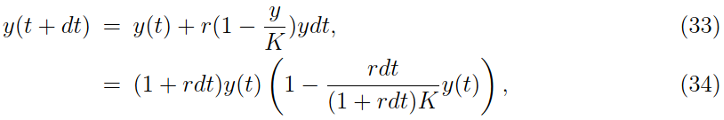

となる。更に変数を置き換え、

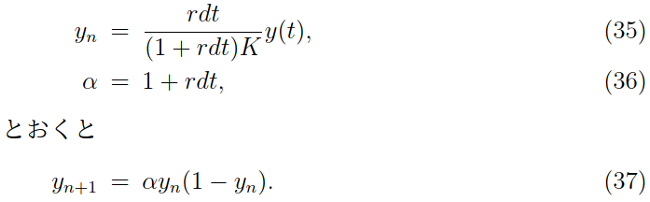

これは、諸君でも簡単に解けそうな(解けないけれど)漸化式であり、ロジスティック写像もしくは離散型ロジスティック方程式と呼ばれている。この数列がn →∞で収束するとすれば(yn+1=yn)、その値は0か1-1/αである。αを変えながら様々な初期値y0で計算してみよう。図2は横軸がｎで縦軸がynである。n=0から20まで計算してある。

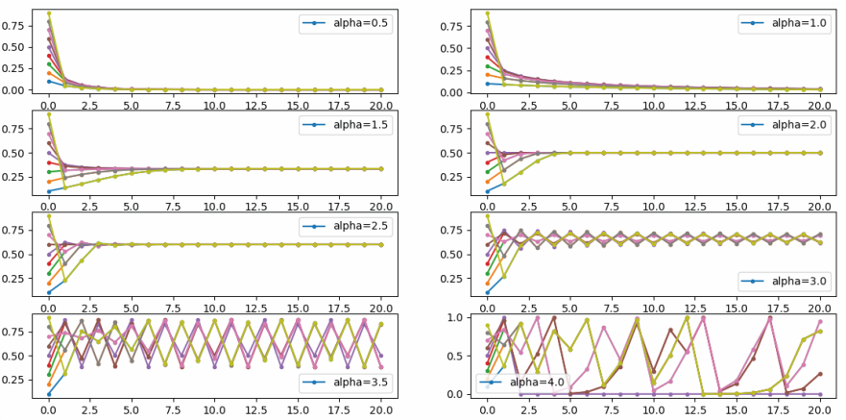

図2　横軸がｎで縦軸がyn

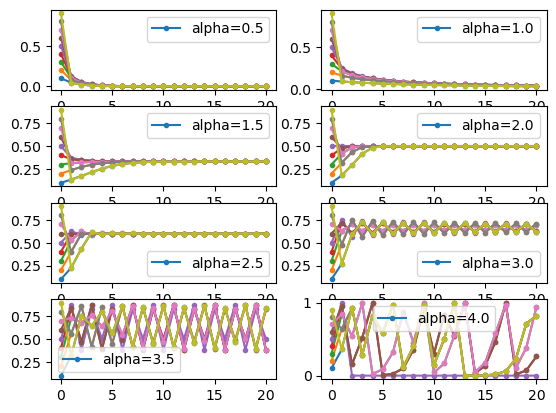

In [26]:
import numpy as np
import matplotlib.pyplot as plt

def logistic(a,y0):
    y=[y0]        # yは1成分リストで、y[0]=y0
    for n in range(1,21): # n=1から20まで
        y.append(a * y[-1] * (1 - y[-1]))
    return y
    
cn=1
for a in np.arange(0.5, 4.5, 0.5): # aは0.5から4.0まで0.5ステップ
    plt.subplot(4, 2, cn) #縦に4図、横に2図配置のcn番目の図
    for y0 in np.arange(0.1, 1.0, 0.1): # y0は0.1から0.9まで0.1ステップ
        yn=logistic(a,y0)
        plt.plot(yn,  ".-")
    plt.legend(["alpha="+ str(a)])
    cn += 1
plt.show()


0や1-1/αにすんなり収束するような単純な振る舞いをするのはαが小さい場合であり、大きくなると奇妙な振る舞いをする。
　どのように収束していくのか調べよう。αを0.5から4とし、この範囲のαに対してynをn=0からn=499まで計算して最後の方の100個、n=399-499を取り出す。横軸をα、縦軸をn=399-499までのynとして図3にプロットした。

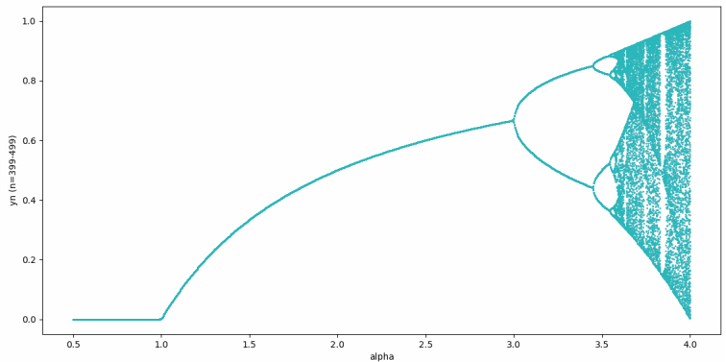

図3　横軸α、縦軸n=399-499までのyn

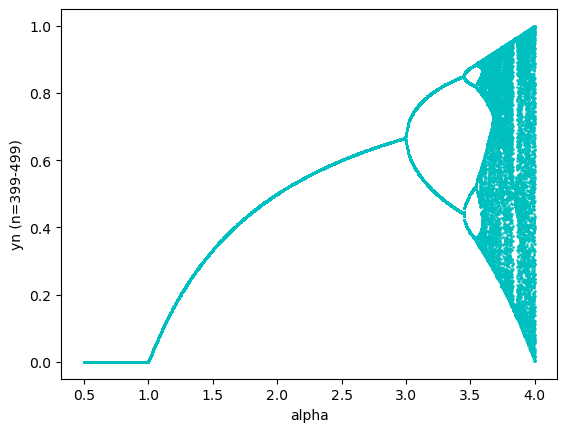

In [27]:
import numpy as np
import matplotlib.pyplot as plt

nmax=500
def logistic(a,y0):
    y=[y0]        # yは1成分リストで、y[0]=y0
    for n in range(1,nmax): # n=1からnmax-1まで
        y.append(a * y[-1] * (1 - y[-1]))
    return y

y0=0.8
for a in np.linspace(0.5, 4.0, 1000): # aは0.5から4まで1000分轄
    yn = logistic(a,y0)[-100:] #計算結果はリストであり、最後の100要素
    an = [a]*len(yn)  # ynと同じ要素数のリストで、各成分は全てa
    plt.plot(an,yn, "c.", markersize=1.7)
plt.xlabel("alpha")
plt.ylabel("yn (n=399-499)")
plt.show()


図3を見て分かるように、αが1より小さいと0に収束し、1-3以下なら1つの値に収束し、3-3.5の時は2個の値を交互にとり、そこから上は、4個の値になり、後は複雑な振る舞いをする。先の図2のα=4は奇妙な振る舞いをしている。
　αが3.5以上の場合が興味深そうなので、α=3.8として詳しく調べた結果を図4に示す。図4(a)は図2と同じでy0を0.1から0.9まで変えて計算した結果であり、収束する気配が無いのは前と同様である。図4(b)は、y0=0.8として、n=200まで計算した場合である。単に収束する気配が無いだけでなく、乱数のようにランダムに変化して、実際に数列を計算しない限り先の値についてはおおまかな値すら予測できないことが分かる。図4(c)は、y0=0.8からy0=0.81まで10分轄、すなわち、y0=0.8, 0.801, 0.802,0.803,...,0.809で計算した結果である。n=4くらいから値がばらつき始めているのがわかる。図4(d)は、y0=0.8からy0=0.8001まで10分轄、すなわち、y0=0.8, 0.80001, 0.80002,0.80003,...,0.80009で計算した結果である。n=16くらいから値がばらつき始めているのがわかる。図4(e)は、y0=0.8からy0=0.800001まで10分轄であり、n=23くらいから値がばらつき始めているのがわかる。図4(f)は、y0=0.8からy0=0.80000001まで10分轄であり、n=34くらいから値がばらつき始めているのがわかる。初期条件y0の僅かな差でも、少し先へ行くと大きな違いを生じていることが分かる。初期条件の誤差を1/100に減らしてもnでいえば10程度先まで一致するようにできるだけであることも分かる。

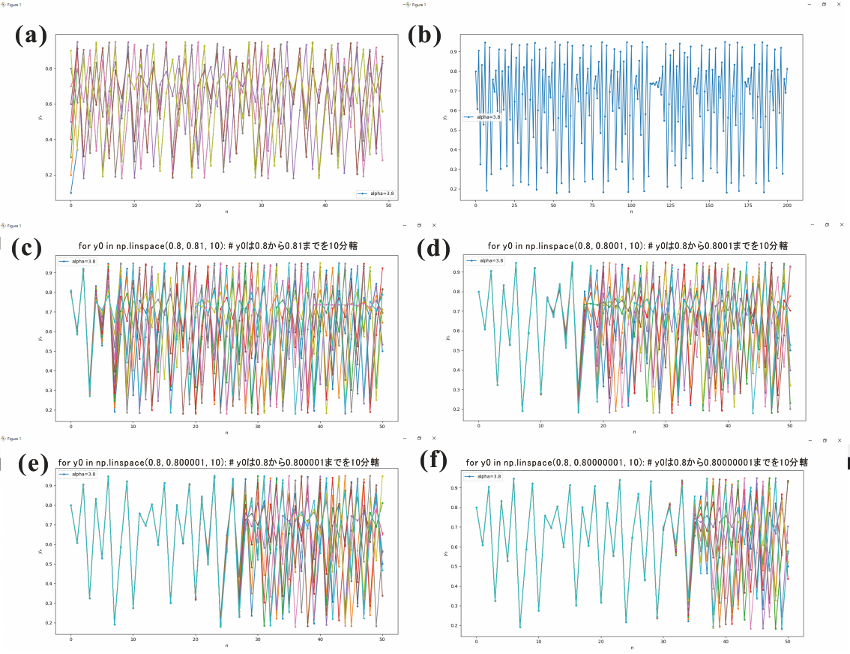

図4　α=3.8。横軸ｎ、縦軸yn



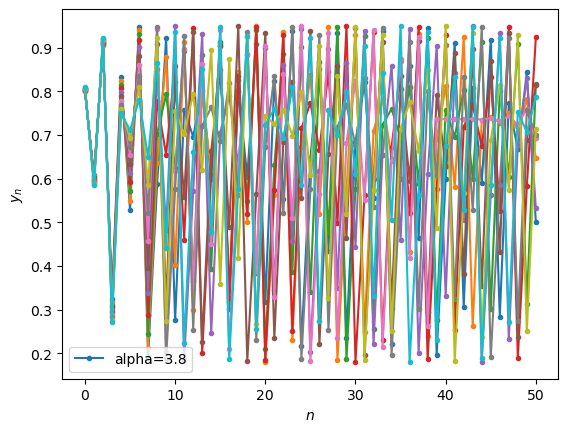

In [28]:
import numpy as np
import matplotlib.pyplot as plt

def logistic(a,y0):
    y=[y0]        # yは1成分リストで、y[0]=y0
    for n in range(1,51): # n=1から50まで
        y.append(a * y[-1] * (1 - y[-1]))
    return y
    
a=3.8
#for y0 in np.arange(0.1, 1.0, 0.1): # y0は0.1から0.9まで0.1ステップ
#for y0 in np.arange(0.8, 0.9, 0.1): # y0は0.8
for y0 in np.linspace(0.8, 0.81, 10): # y0は0.8から0.81までを10分轄
    yn=logistic(a,y0)
    plt.plot(yn,  ".-")
    plt.legend(["alpha="+ str(a)])
plt.xlabel("$n$")
plt.ylabel("$y_n$")
plt.show()


何気なく説明したが、式(37)のように簡単な漸化式でもこのように複雑な振る舞いをすることが数理解析に及ぼした影響は極めて大きい。

　初期条件の誤差を1/100に減らしてもn=10程度先でばらついてしまうことは、初期条件の微小差に対して、数列の値が指数関数的に増大することを意味している。このような振る舞い(初期条件の僅かな差が時間とともに指数関数的に増大する)に対してカオスchaosという名前が付けられて、他の系でも詳しく調べてられている。式(37)は1元の漸化式であるが、SIRモデルのような3元1階以上の常微分方程式はカオスになる場合があり、歴史的にはローレンツモデルが重要な役割をしている。Lotka-Volterra equationsのような2元1階の場合やLogistic equationのように1元1階の常微分方程式はカオスにならない。もともと、Logistic equationの解析から生じたカオスなのに不思議に思うかもしれないが、dtを有限の大きさにしてオイラー法で差分化したことの影響である。実際、Logistic equationには厳密解(式(2))があり、初期条件y0の僅かな差が時間と共に指数関数的に増大することは無い。3元1階以上の常微分方程式にカオスになる場合があるのは、時間を離散化した近似に伴う影響ではなく、方程式系そのものの持つ性質である。

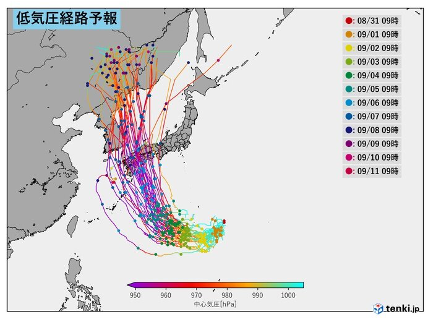

図5　台風の進路　tenki.jp

　なぜ、天気予報は長期予報ができないか？現代の進んだコンピュータや観測技術でも1週間先の天気予報も怪しい。技術が未熟なのであり、「100年先には、1年後の天気予報も正確にできるようになるはず」なのか否か。気象は地球大気の織り成す現象であり、相応の数理モデルを作成することができる。数理モデルは微分方程式であり、カオスになることが知られている。したがって、どんなに高精度な数理モデルを用いても、初期条件の誤差は指数関数的に増大する。これが現在の技術で長期予報のできない理由である。図4でn=200の値を正確に求めようとしたら、初期条件y0の誤差をどのくらい小さくする必要があるのか考えて見よ。また、モデルに入れていない些細な効果、例えばどこかで1頭の蝶々がどのように羽ばたいたか等も将来に大きな影響を及ぼすという結論になる（この真偽は分からず現在でも論争中であり、業界ではバタフライ効果という）。微分方程式を用いた現在のシステムで正確な長期予報ができないのは確かであるが、例えば、台風では、図5のように初期条件などを変えて多数のシミュレーションを行い、進路予想を確率で行っている。　　　　　　　　　　　　　　　　　　　
どこかを改良するとカオスの抑制ができる可能性はあり、また微分方程式ではなく経験則（人工知能）を用いれば出来るかもしれない。したがって、天気の長期予報の可能性が完全に否定されたわけではなく、天気予報の方法は膨大な需要から現在も様々な観点で精力的な研究がなされている。天気よりも、地震や噴火の長期予報の方が初期条件を把握できていないという点で、現在は難しい。

コーヒーカップにミルクを入れてかき混ぜると、両者は良く混ざる。当たり前の現象ではあるが、流体の運動が乱流とよばれるカオス状態になるから、初期状態では一か所にまとまっていたミルクがカップ全体に広がる。図4(f)のような振る舞いはこのように解釈できる。

図4(b)は、まるで乱数のように規則性の見出せない数列であるが、実際は式(37)に従う簡単な漸化式を計算しただけである。見方を変えると、世の中にはランダムと思えるような複雑な振る舞いをする現象が無数にあるが、実は極めて簡単な法則に支配されている場合もあるかもしれない。心臓の鼓動の揺らぎや神経細胞の振る舞いをこのような観点から研究している人もいる。


7.1　パイこね変換

先に述べたように、カオスの特徴は不規則にばらつき広がる、すなわち混ざることである。ここでは、どのようにして混ざるのか機構を調べてみよう。

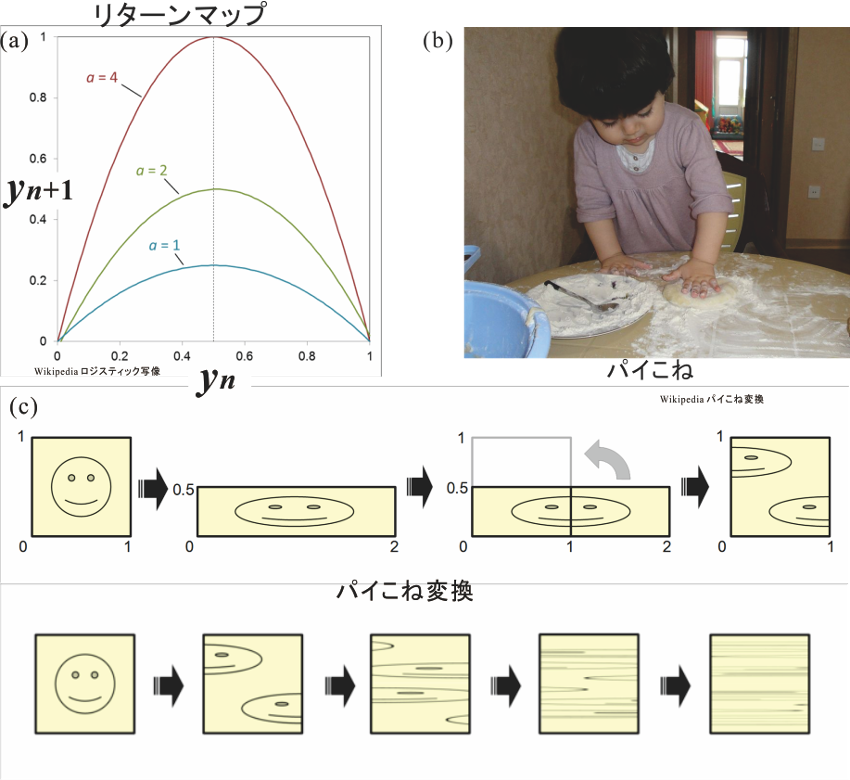

図(a)は式(37)のynとyn+1との関係を示した図である。ynが0.5までは単調に増加、すなわち多少の不均一はあるが引き延ばしただけである。しかし、0.5から1の場合には、引き延ばしてひっくり返している。この操作はパイをこねる場合によく似ている。パイをこねる場合、引き延ばし、折り畳み、引き延ばし折り畳みを繰り返す。このため、ynとyn+1との間に図(a)のような関係がある場合をパイこね変換とよぶ。ロジステック写像の混ざり方は、パイこね変換の典型例である。図(a)のようなynとyn+1との関係を示した図をリターンマップという。

7.2　　微分方程式のカオス例：ローレンツモデル

ローレンツモデルは、大気の流れ(気象)を研究する中でモデル化された式、

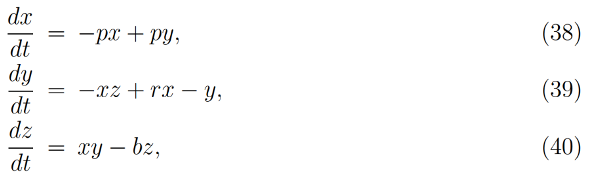

であるが、抽象化が著しいので現実との対応はあまり気にしなくてよい。この系は、変数x,y,zの振る舞いがパラメータp,r,bで決められる。
 時間変化しない点(不動点)はdx/dt=dy/dt=dz/dt=0で求まり、3か所あり、

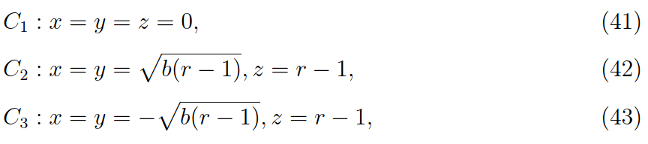

である。C1は安定で、C1近傍にいると、C1になる。C2,C3は不安定な場合があり、近傍にいても遠くへ行ってしまうがまた戻る(業界用語でアトラクターという点)。

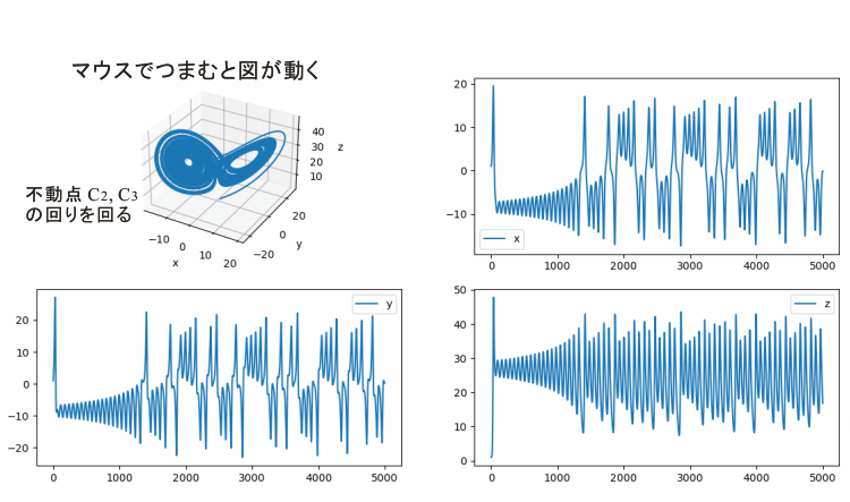

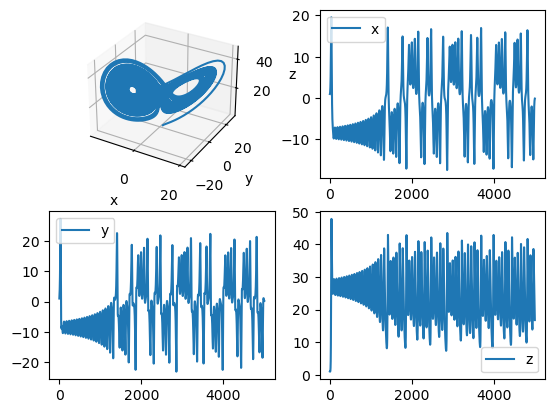

In [31]:
# 3元1階の常微分方程式なので、SIRと同じコードでもよいが、pythonらしく書いてみた。

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# const
p = 10
r = 28
b = 8/3
dt = 0.01
tmax = 50
X0=[x0,y0,z0]=[1, 1, 1]  #初期条件
x = [ ]
y = [ ]
z = [ ]
t = [ ]

def OneStepForward(X,dt):  #Xはnumpyの配列(x,y,z)
    k1 = LorenzEquation(X)
    k2 = LorenzEquation(X + k1*dt/2)
    k3 = LorenzEquation(X + k2*dt/2)
    k4 = LorenzEquation(X + k3*dt)
    return  X + dt/6*(k1 + 2*k2 + 2*k3 + k4)

def LorenzEquation(X):    #Xはnumpyの配列(x,y,z)
    xx,yy,zz = X
    return np.array([-p*xx + p*yy, -xx*zz + r*xx - yy, xx*yy - b*zz])

tprev=0
xprev,yprev,zprev=X0
while tprev < tmax :
    x.append(xprev)
    y.append(yprev)
    z.append(zprev)
    t.append(tprev)
    [xprev,yprev,zprev] = OneStepForward([xprev,yprev,zprev], dt)
    tprev += dt

fig = plt.figure()
ax = fig.add_subplot(221, projection='3d')
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.plot(x,y,z)
ax2 = fig.add_subplot(2,2,2)
ax2.plot(x)
ax2.legend(["x"])
ax3 = fig.add_subplot(2,2,3)
ax3.plot(y)
ax3.legend(["y"])
ax4 = fig.add_subplot(2,2,4)
ax4.plot(z)
ax4.legend(["z"])
plt.show()


かなり不規則であるが、x,y,zは振動運動しているのがわかる。ｚ成分に注目して、極大値を取り出して特徴を調べてみよう。

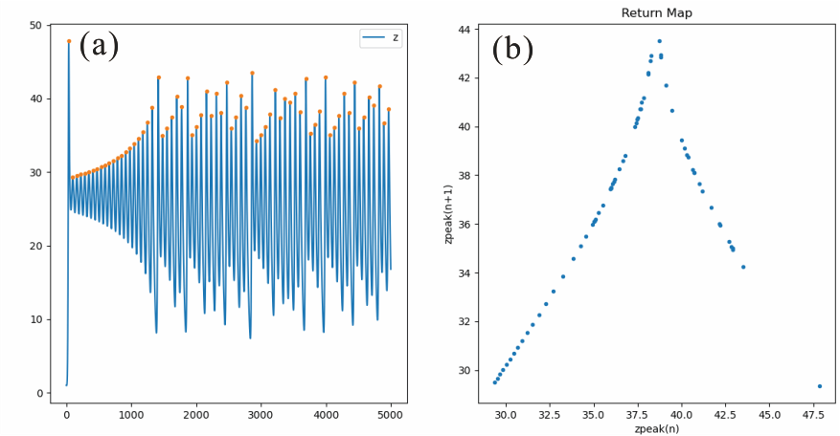

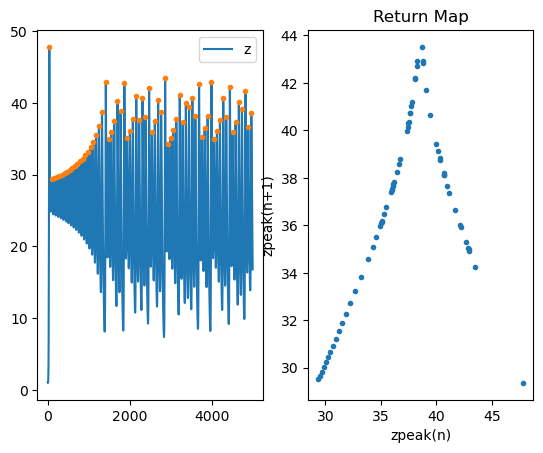

In [32]:
# 3元1階の常微分方程式なので、SIRと同じコードでもよいが、pythonらしく書いてみた。

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# const
p = 10
r = 28
b = 8/3
dt = 0.01
tmax = 50
X0=[x0,y0,z0]=[1, 1, 1]
x = [ ]
y = [ ]
z = [ ]
t = [ ]

def OneStepForward(X,dt):  #Xはnumpyの配列(x,y,z)
    k1 = LorenzEquation(X)
    k2 = LorenzEquation(X + k1*dt/2)
    k3 = LorenzEquation(X + k2*dt/2)
    k4 = LorenzEquation(X + k3*dt)
    return  X + dt/6*(k1 + 2*k2 + 2*k3 + k4)

def LorenzEquation(X):    #Xはnumpyの配列(x,y,z)
    xx,yy,zz = X
    return np.array([-p*xx + p*yy, -xx*zz + r*xx - yy, xx*yy - b*zz])

tprev=0
xprev,yprev,zprev=X0
while tprev < tmax :
    x.append(xprev)
    y.append(yprev)
    z.append(zprev)
    t.append(tprev)
    [xprev,yprev,zprev] = OneStepForward([xprev,yprev,zprev], dt)
    tprev += dt

#極大値を見つける
zpeakN= (np.diff(np.sign(np.diff(z))) < 0).nonzero()[0] + 1 # local max
zpeak = [z[n] for n in zpeakN]

fig = plt.figure()
ax = fig.add_subplot(1,2,1)
ax.plot(z)
ax.legend(["z"])
ax.plot(zpeakN, zpeak,".")

ax2 = fig.add_subplot(1,2,2,title="Return Map", xlabel="zpeak(n)", ylabel="zpeak(n+1)")
ax2.plot(zpeak[0:-1], zpeak[1:],".")
plt.show()


図(a)は前に計算したｚ成分と同じであるが、極大値を抽出して、抽出した値をプロットしてある。適切に極大値が見つけられているのが分かる。図(b)は極大値の数列zpeak[n]を用いたリターンマップであり、横軸をzpeak[n]、縦軸をzpeak[n+1]としてプロットした。カオスの特徴であるパイこね変換になっているのがわかる。
　諸君が研究を行うと神経細胞のインパルスのような多様な不規則信号に出会う。計測は容易であるが、全くもってどのように解析したら良いか分からない場合がほとんどである。適当にデータを処理して、ここで述べたリターンマップを作成してパイこね変換になっていれば、カオスの可能性が高く、単純な規則が内在している可能性がある。カオスの特徴は、決定論的な単純な操作であるにもかかわらず、任意の近接した2点間の距離が、時間や操作回数に対して指数関数的に増大し、たとえ近似値であっても実際に計算することなしには求められないことであり、パイこね変換はこの条件を満たしている。


課題

1.）上記1-7を実行せよ

2.）「6 　SIRモデルを現実に合わせる」で示したpython codeは不完全であり使いにくいだけでなく、現実に合っていない。SIRモデルの改良も含めてcodeを修正し、できる範囲でよいので、現実に合うようにしてみよ（難しいので無理をしないこと）。また、感染症の蔓延について考察せよ。

3.）ローレンツモデルがカオスになることを数値計算で示せ。初期条件の僅かな差が指数関数的に増大することを示せばよい。

4.) 例示以外の微分方程式か数列を数値計算し、カオス的振る舞いをするか否か考察せよ。

5.）数値シミュレーションの可能性、難しさ、落とし穴などについて感想を述べよ。

レポートについて
1)	題名は「Pythonによる微分方程式の数値計算」として、ここで述べた課題を全て含むようにしてまとめ、1つのファイルにしてK-LMSから提出せよ。
2)	レポートのファイル名例：
　　　　　　　　　13B99慶応太郎pythonコメントがあれば記載.pdf
3)	締め切りは2024年10月1日(火)。
4)	出来ない問・課題に対しては出来ない理由を考察し、全ての問・課題に対して答えよ。
5)	友人・知人と相談してもよいし実験を手伝ってもらってもよい、他人のレポートを参照しても良い。他人の世話になった時には、世話になった個所を明記し、謝辞に記載すること。他人の世話になってもよいのは、物理学実験独自の規則であり、他科目は違うから気を付けること。
